# 응용 실습 : 베어링 결함 진단 - RNN으로 진동 신호 분류하기
--------------
## 실습 가이드
    1. 데이터를 다운로드하여 Colab에 불러옵니다.
    2. 필요한 라이브러리 임포트 코드는 작성되어 있습니다.
    3. 코드를 순서대로 아래의 빈칸을 채워나갑니다.
    4. 전체 실행 결과는 맨 첫 번째 셀에서 확인할 수 있습니다.

## 문제 소개  
    - 이번 실습에서는 CWRU(Case Western Reserve University) Bearing Dataset을 사용합니다.
    - 회전 기계에서 수집된 진동 신호 데이터로, 기계공학에서 가장 널리 쓰이는 결함 진단 벤치마크 데이터셋입니다.

  ![bearing image](https://upload.wikimedia.org/wikipedia/commons/thumb/9/9c/Rolling_element_bearing.png/320px-Rolling_element_bearing.png)

     데이터의 구성은 다음과 같습니다.  
    (a) 1728 rpm 전동기에 부착된 가속도 센서에서 12,000 Hz로 샘플링된 진동 신호  
    (b) 총 4개의 클래스: 정상(Normal) / 내륜 결함(Inner Race) / 볼 결함(Ball) / 외륜 결함(Outer Race)

- 데이터 출처: [CWRU Bearing Data Center](https://engineering.case.edu/bearingdatacenter/download-data-file)

## 학습 목표

    - Ch01에서 배운 RNN 이미지 분류 구조를 진동 신호에 응용한다.
    - 1D 진동 신호를 2D 배열(이미지처럼)로 변환하는 방법을 이해한다.
    - 신호를 윈도우(window)로 분할하여 학습 데이터를 구성하는 방법을 익힌다.
    - MNIST의 (28, 28) 구조처럼, 진동 신호도 (32, 32) 형태로 만들어 RNN에 입력할 수 있음을 이해한다.

## Ch01과의 비교

| Ch01 (MNIST) | 이번 실습 (CWRU) |
|---|---|
| 손글씨 이미지 (28, 28) | 진동 신호 윈도우 (32, 32) |
| 픽셀 값 0~255 | 가속도 센서 값 (연속값) |
| 0~9 숫자 분류 (10 클래스) | 결함 종류 분류 (4 클래스) |
| SimpleRNN → Dense(10) | SimpleRNN → Dense(4) |

- 제작 : 전승윤
---

## 데이터 다운로드 방법

아래 링크에서 `.mat` 파일 4개를 다운로드한 후, Colab에 업로드하거나 Google Drive에 올려두세요.

**다운로드 링크**: https://engineering.case.edu/bearingdatacenter/download-data-file

필요한 파일 (모두 **0 HP** 부하, **0.007 inch** 결함 크기 기준):

| 파일명 | 클래스 |
|---|---|
| `Normal_0.mat` | 0 - 정상 |
| `IR007_0.mat` | 1 - 내륜 결함 |
| `B007_0.mat` | 2 - 볼 결함 |
| `OR007@6_0.mat` | 3 - 외륜 결함 |

> 💡 파일이 없어도 **Step 1 문제 3**에서 합성 데이터로 대체 실행할 수 있습니다.

In [19]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.layers import SimpleRNN, Dense, Input
from keras.models import Model
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

SEED = 34
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Step 1. 데이터 기본 처리
---

### 문제 1. .mat 파일에서 진동 신호를 불러오는 함수를 작성하세요.

CWRU 데이터는 MATLAB 파일(.mat) 형식입니다.  
`scipy.io.loadmat()`으로 불러온 뒤, 키 이름에 `DE_time`이 포함된 변수를 찾아 1차원 배열로 반환하세요.

**힌트**: `.mat` 파일을 dict처럼 다룰 수 있으며, `mat.keys()`로 변수 이름 목록을 확인할 수 있습니다.

In [21]:
def load_cwru_signal(filepath):
    """
    .mat 파일에서 Drive End 가속도 신호를 불러옵니다.
    반환: 1차원 numpy 배열
    """
    mat = scipy.io.loadmat(filepath)
    # DE_time이 포함된 키를 찾아 flatten()으로 1D 배열 반환
    for key in mat.keys():
        if 'DE_time' in key:
            return mat[key].flatten()
    raise ValueError(f"'DE_time' 변수를 찾을 수 없습니다: {filepath}")

In [22]:
import os
print(os.listdir('/content/drive/'))
print(os.listdir('/content/drive/MyDrive/'))
print(os.listdir('/content/drive/MyDrive/Colab Notebooks/'))
print(os.listdir('/content/drive/MyDrive/Colab Notebooks/배운거 응용/'))
print(os.listdir('/content/drive/MyDrive/Colab Notebooks/배운거 응용/CWRU/'))
print(os.listdir('/content/drive/MyDrive/Colab Notebooks/배운거 응용/CWRU/raw/'))




['.shortcut-targets-by-id', 'Othercomputers', 'MyDrive', '.Trash-0', '.Encrypted']
['Colab Notebooks', '1차 관련 데이터', '2차 관련 데이터']
['배운거 응용', '딥러닝 300제', '1차', '2차', '로컬 연결', 'Untitled']
['CWRU', '베어링 결함 진단_RNN으로 진동 신호 분류하기_3.26.ipynb']
['raw']
['Time_Normal_1_098.mat', 'B007_1_123.mat', 'OR007_6_1_136.mat', 'IR007_1_110.mat']


### 문제 2. 4개의 파일을 불러와 각 신호의 길이(샘플 수)를 출력하세요.

In [23]:
# 파일 경로 설정 (Colab에 업로드한 경우 경로 수정)
DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/배운거 응용/CWRU/raw/'


signal_normal = load_cwru_signal(DATA_DIR + 'Time_Normal_1_098.mat')
signal_inner  = load_cwru_signal(DATA_DIR + 'IR007_1_110.mat')
signal_ball   = load_cwru_signal(DATA_DIR + 'B007_1_123.mat')
signal_outer  = load_cwru_signal(DATA_DIR + 'OR007_6_1_136.mat')

print('정상(Normal) 신호 길이   :', len(signal_normal))
print('내륜 결함(Inner) 신호 길이:', len(signal_inner))
print('볼 결함(Ball) 신호 길이  :', len(signal_ball))
print('외륜 결함(Outer) 신호 길이:', len(signal_outer))

정상(Normal) 신호 길이   : 483903
내륜 결함(Inner) 신호 길이: 486224
볼 결함(Ball) 신호 길이  : 487384
외륜 결함(Outer) 신호 길이: 486804


### 문제 3. (파일 없을 경우 대체) 합성 신호로 실습하기

파일을 다운로드하지 못한 경우 아래 셀을 실행하세요.  
각 클래스를 주파수가 다른 사인파로 근사하여 실습용 신호를 생성합니다.

In [24]:
# 실제 파일이 있으면 이 셀은 건너뛰세요
# 합성 신호 생성 (각 클래스를 다른 주파수의 사인파로 근사)
fs = 12000  # 샘플링 주파수
N = 120000  # 신호 길이 (10초)
t = np.linspace(0, N/fs, N)

np.random.seed(SEED)
signal_normal = np.sin(2 * np.pi * 50  * t) + 0.1 * np.random.randn(N)  # 50 Hz
signal_inner  = np.sin(2 * np.pi * 162 * t) + 0.1 * np.random.randn(N)  # 162 Hz (BPFI 근사)
signal_ball   = np.sin(2 * np.pi * 141 * t) + 0.1 * np.random.randn(N)  # 141 Hz (BSF 근사)
signal_outer  = np.sin(2 * np.pi * 107 * t) + 0.1 * np.random.randn(N)  # 107 Hz (BPFO 근사)

print('합성 신호 생성 완료')
print('각 신호 길이:', len(signal_normal))

합성 신호 생성 완료
각 신호 길이: 120000


---
## Step 2. 전처리 - 신호 분할 및 2D 변환
---

### Ch01과의 핵심 연결 포인트

MNIST에서 (28, 28) 이미지 = 28개의 타임스텝 × 28개의 픽셀  
→ 이번 실습에서는 **1024 샘플 신호 윈도우를 (32, 32)로 reshape**하여 동일하게 처리합니다.

```
1D 신호: [x0, x1, x2, ..., x1023]  (길이 1024)
         ↓ reshape(32, 32)
2D 배열: [[x0,   x1,  ..., x31],
          [x32,  x33, ..., x63],
          ...
          [x992, x993,...,x1023]]   → RNN이 32개 행을 순서대로 처리
```

### 문제 4. 신호를 윈도우 단위로 분할하는 함수를 작성하세요.

- `window_size=1024`, `stride=256`으로 슬라이딩 윈도우 분할
- 각 윈도우를 (32, 32)로 reshape
- 반환: shape (윈도우 수, 32, 32)

In [25]:
def segment_signal(signal, window_size=1024, stride=256):
    """
    1D 신호를 슬라이딩 윈도우로 분할 후 (32, 32)로 reshape합니다.
    반환: shape (윈도우 수, 32, 32)
    """
    segments = []
    for start in range(0, len(signal) - window_size, stride):
        window = signal[start : start + window_size]
        segments.append(window.reshape(32, 32))
    return np.array(segments)


def split_and_segment(signal, window_size=1024, stride=256, train_ratio=0.8):
    """
    신호를 먼저 train/test 구간으로 나눈 뒤 각각 윈도우 생성.
    (데이터 누수 방지: 겹치는 윈도우가 train/test에 동시에 들어가지 않도록)
    """
    split_idx = int(len(signal) * train_ratio)
    train_seg = segment_signal(signal[:split_idx], window_size, stride)
    test_seg  = segment_signal(signal[split_idx:], window_size, stride)
    return train_seg, test_seg


### 문제 5. 4개 신호를 분할하고 shape를 확인하세요.

이전 방법(랜덤 split)과의 차이:


In [26]:
tr_normal, te_normal = split_and_segment(signal_normal)
tr_inner,  te_inner  = split_and_segment(signal_inner)
tr_ball,   te_ball   = split_and_segment(signal_ball)
tr_outer,  te_outer  = split_and_segment(signal_outer)

print("--- Train ---")
print("정상(Normal) shape  :", tr_normal.shape)
print("내륜 결함(Inner) shape:", tr_inner.shape)
print("볼 결함(Ball) shape  :", tr_ball.shape)
print("외륜 결함(Outer) shape:", tr_outer.shape)
print("--- Test ---")
print("정상(Normal) shape  :", te_normal.shape)
print("내륜 결함(Inner) shape:", te_inner.shape)


정상(Normal) shape  : (465, 32, 32)
내륜 결함(Inner) shape: (465, 32, 32)
볼 결함(Ball) shape  : (465, 32, 32)
외륜 결함(Outer) shape: (465, 32, 32)


### 문제 6. 4개 클래스의 데이터를 합치고 레이블을 만드세요.

- `np.concatenate`로 데이터 합치기
- 레이블: 정상=0, 내륜=1, 볼=2, 외륜=3
- `to_categorical`로 one-hot 인코딩 (Ch01과 동일)

In [27]:
# Train / Test 각각 합치기
train_images = np.concatenate([tr_normal, tr_inner, tr_ball, tr_outer])
test_images  = np.concatenate([te_normal, te_inner, te_ball, te_outer])

# 레이블 생성 (0: 정상, 1: 내륜, 2: 볼, 3: 외륜)
train_y_raw = np.concatenate([
    np.zeros(len(tr_normal)), np.ones(len(tr_inner)),
    np.full(len(tr_ball), 2), np.full(len(tr_outer), 3)
])
test_y_raw = np.concatenate([
    np.zeros(len(te_normal)), np.ones(len(te_inner)),
    np.full(len(te_ball), 2), np.full(len(te_outer), 3)
])

# One-hot 인코딩
train_labels = to_categorical(train_y_raw, num_classes=4)
test_labels  = to_categorical(test_y_raw,  num_classes=4)

print("train_images shape:", train_images.shape)
print("test_images  shape:", test_images.shape)
print("클래스별 train 샘플 수:", dict(zip([0,1,2,3], [int(np.sum(train_y_raw==i)) for i in range(4)])))
print("클래스별 test  샘플 수:", dict(zip([0,1,2,3], [int(np.sum(test_y_raw==i))  for i in range(4)])))


전체 데이터 shape: (1860, 32, 32)
레이블 shape    : (1860, 4)
클래스별 샘플 수  : {0: np.int64(465), 1: np.int64(465), 2: np.int64(465), 3: np.int64(465)}


### 문제 7. (참고) 신호 단위 분리 vs 랜덤 분리 비교

| 방법 | 설명 | 문제 |
|---|---|---|
| 랜덤 split (이전) | 윈도우 생성 후 섞어서 분리 | 겹치는 윈도우가 train/test 동시 존재 → 100% 정확도 |
| **신호 단위 분리 (현재)** | **앞 80% → train, 뒤 20% → test** | **실제 환경과 유사한 평가** |

In [28]:
# 신호 단위 분리를 사용하므로 train_test_split은 사용하지 않습니다.
# train_images, test_images, train_labels, test_labels는 위 셀에서 이미 생성됐습니다.
print("train_images shape:", train_images.shape)
print("test_images  shape:", test_images.shape)
print("train_labels shape:", train_labels.shape)
print("test_labels  shape:", test_labels.shape)


train_images shape: (1488, 32, 32)
test_images shape : (372, 32, 32)
train_labels shape: (1488, 4)
test_labels shape : (372, 4)


### 문제 8. train/test 데이터의 최솟값/최댓값을 확인하세요. (Ch01 문제 7과 동일)

In [29]:
print('train_images 최솟값:', train_images.min(), '/ 최댓값:', train_images.max())
print('test_images  최솟값:', test_images.min(),  '/ 최댓값:', test_images.max())

train_images 최솟값: -1.4037376254952127 / 최댓값: 1.3708928321701668
test_images  최솟값: -1.4037376254952127 / 최댓값: 1.3708928321701668


### 문제 9. 데이터를 0-1 정규화하세요. (Ch01 문제 9와 동일)

$$normalize(x) = \frac{x - x_{min}}{x_{max} - x_{min}}$$

**주의**: MNIST와 달리 진동 신호는 음수 값을 포함하므로 min-max 정규화를 사용합니다.

In [30]:
x_min = train_images.min()
x_max = train_images.max()

train_images = (train_images - x_min) / (x_max - x_min)
test_images  = (test_images  - x_min) / (x_max - x_min)

print('정규화 후 train_images 최솟값:', train_images.min(), '/ 최댓값:', train_images.max())
print('정규화 후 test_images  최솟값:', test_images.min(),  '/ 최댓값:', test_images.max())

정규화 후 train_images 최솟값: 0.0 / 최댓값: 1.0
정규화 후 test_images  최솟값: 0.0 / 최댓값: 1.0


---
## Step 3. 시각화 확인
---

### 문제 10. 4개 클래스의 원본 진동 신호를 각 500 샘플씩 플롯하세요.

정상과 각 결함 신호의 파형이 다름을 시각적으로 확인합니다.

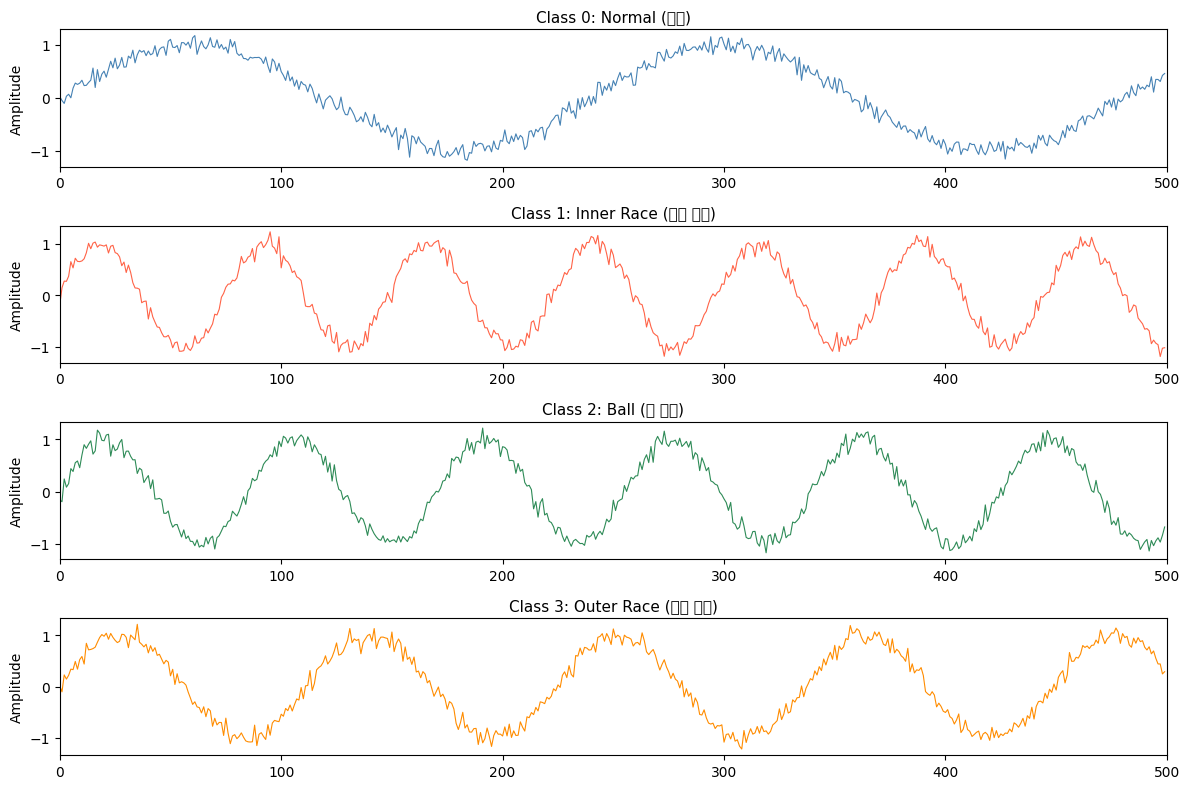

In [31]:
class_names = ['Normal (정상)', 'Inner Race (내륜 결함)', 'Ball (볼 결함)', 'Outer Race (외륜 결함)']
signals = [signal_normal, signal_inner, signal_ball, signal_outer]
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

fig, axes = plt.subplots(4, 1, figsize=(12, 8))
for i, (ax, sig, name, color) in enumerate(zip(axes, signals, class_names, colors)):
    ax.plot(sig[:500], color=color, linewidth=0.8)
    ax.set_title(f'Class {i}: {name}', fontsize=11)
    ax.set_ylabel('Amplitude')
    ax.set_xlim(0, 500)
plt.tight_layout()
plt.show()

### 문제 11. 각 클래스에서 윈도우 1개를 뽑아 (32, 32) 2D 이미지로 시각화하세요.

Ch01에서 MNIST 손글씨를 `imshow`로 시각화한 것과 동일한 방법입니다.  
각 2D 배열은 RNN이 처리할 "신호 이미지"입니다.

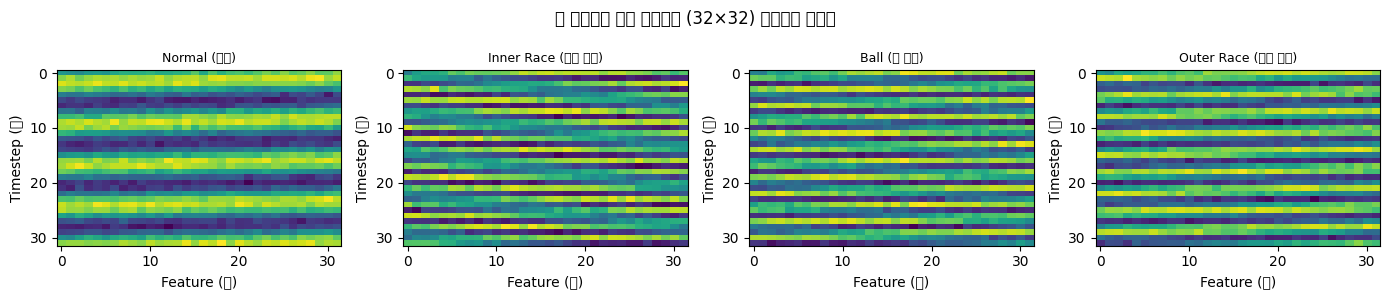

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
samples = [tr_normal[0], tr_inner[0], tr_ball[0], tr_outer[0]]

for ax, sample, name in zip(axes, samples, class_names):
    ax.imshow(sample, cmap='viridis', aspect='auto')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Feature (열)')
    ax.set_ylabel('Timestep (행)')

plt.suptitle('각 클래스의 신호 윈도우를 (32×32) 이미지로 시각화', fontsize=12)
plt.tight_layout()
plt.show()


---
## Step 4. 모델 설계 (Ch01과 거의 동일)
---

### 문제 12. SimpleRNN 모델을 설계하세요.

Ch01과의 차이는 **입력 shape**와 **출력 클래스 수**뿐입니다.

| | Ch01 (MNIST) | 이번 실습 |
|---|---|---|
| Input shape | (28, 28) | **(32, 32)** |
| SimpleRNN units | 64 | 64 |
| Dense units | 10 (0~9) | **4 (결함 4종)** |
| activation | softmax | softmax |

In [33]:
from keras.layers import SimpleRNN, Dense, Input
from keras.models import Model

# Ch01과 동일한 구조, input shape와 출력 클래스 수만 변경
inputs = Input(shape=(32, 32))             # (32 timesteps, 32 features)
x = SimpleRNN(64, activation='tanh')(inputs)
outputs = Dense(4, activation='softmax')(x)  # 4 클래스 분류

model = Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,468 (25.27 KB)

 Trainable params: 6,468 (25.27 KB)

 Non-trainable params: 0 (0.00 B)

### 문제 13. 모델을 컴파일하세요. (Ch01과 동일)

In [34]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

---
## Step 5. 학습
---

### 문제 14. 모델을 학습시키세요. (Ch01과 동일)

- epochs=10, batch_size=64
- validation_data로 test 데이터 사용

In [35]:
hist = model.fit(
    train_images, train_labels,
    validation_data=(test_images, test_labels),
    epochs=10,
    batch_size=64,
    verbose=2
)

Epoch 1/10
24/24 - 6s - 270ms/step - accuracy: 0.3810 - loss: 1.3662 - val_accuracy: 0.6129 - val_loss: 1.2052
Epoch 2/10
24/24 - 0s - 9ms/step - accuracy: 0.7083 - loss: 0.9242 - val_accuracy: 0.7715 - val_loss: 0.8145
Epoch 3/10
24/24 - 0s - 9ms/step - accuracy: 0.8824 - loss: 0.6029 - val_accuracy: 0.9516 - val_loss: 0.4630
Epoch 4/10
24/24 - 0s - 9ms/step - accuracy: 0.9698 - loss: 0.3388 - val_accuracy: 1.0000 - val_loss: 0.2164
Epoch 5/10
24/24 - 0s - 9ms/step - accuracy: 0.9886 - loss: 0.1993 - val_accuracy: 1.0000 - val_loss: 0.1702
Epoch 6/10
24/24 - 0s - 9ms/step - accuracy: 1.0000 - loss: 0.1206 - val_accuracy: 1.0000 - val_loss: 0.0788
Epoch 7/10
24/24 - 0s - 9ms/step - accuracy: 1.0000 - loss: 0.0568 - val_accuracy: 1.0000 - val_loss: 0.0394
Epoch 8/10
24/24 - 0s - 10ms/step - accuracy: 1.0000 - loss: 0.0325 - val_accuracy: 1.0000 - val_loss: 0.0260
Epoch 9/10
24/24 - 0s - 9ms/step - accuracy: 1.0000 - loss: 0.0233 - val_accuracy: 1.0000 - val_loss: 0.0199
Epoch 10/10
24/2

### 문제 15. 학습 곡선을 시각화하세요.

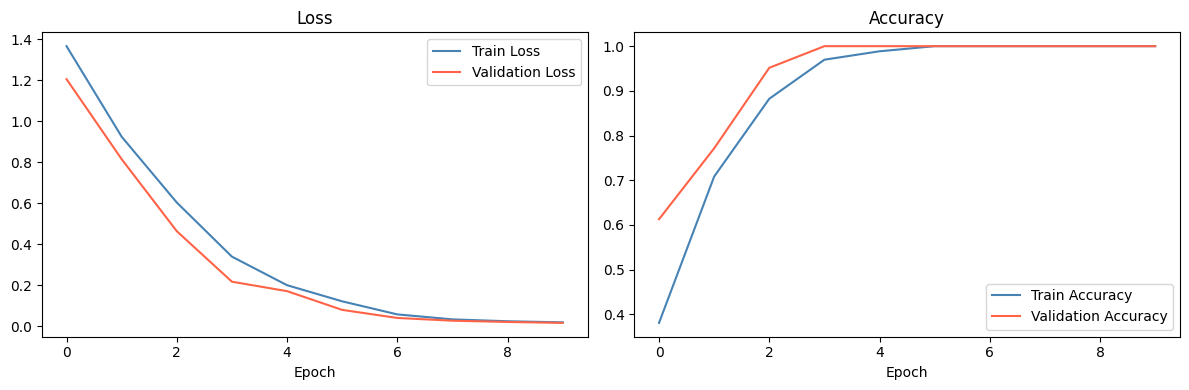

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(hist.history['loss'],     label='Train Loss',      color='steelblue')
axes[0].plot(hist.history['val_loss'], label='Validation Loss', color='tomato')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Accuracy
axes[1].plot(hist.history['accuracy'],     label='Train Accuracy',      color='steelblue')
axes[1].plot(hist.history['val_accuracy'], label='Validation Accuracy', color='tomato')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Step 6. 평가
---

### 문제 16. test 데이터로 최종 성능을 평가하세요. (Ch01과 동일)

In [37]:
loss, acc = model.evaluate(test_images, test_labels, verbose=0)
print(f'Test Loss    : {loss:.4f}')
print(f'Test Accuracy: {acc:.4f} ({acc*100:.2f}%)')

Test Loss    : 0.0153
Test Accuracy: 1.0000 (100.00%)


### 문제 17. 샘플 1개를 예측하고 결과를 바 차트로 시각화하세요. (Ch01 문제 참고)

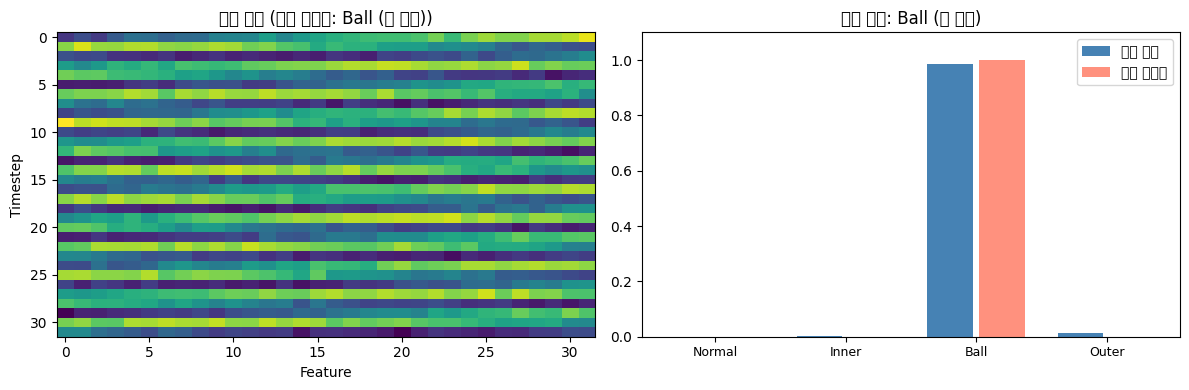

실제 클래스  : Ball (볼 결함)
예측 클래스  : Ball (볼 결함)
예측 확률    : ['0.000', '0.004', '0.984', '0.012']


In [38]:
sample_idx = 10
pred = model.predict(test_images[sample_idx:sample_idx+1], verbose=0)
true = test_labels[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽: 입력 신호 이미지
axes[0].imshow(test_images[sample_idx], cmap='viridis', aspect='auto')
axes[0].set_title(f'입력 신호 (실제 클래스: {class_names[np.argmax(true)]})')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Timestep')

# 오른쪽: 예측 확률 바 차트
x_pos = np.arange(4)
axes[1].bar(x_pos - 0.2, pred[0], width=0.35, label='예측 확률', color='steelblue')
axes[1].bar(x_pos + 0.2, true,    width=0.35, label='실제 레이블', color='tomato', alpha=0.7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['Normal', 'Inner', 'Ball', 'Outer'], fontsize=9)
axes[1].set_ylim(0, 1.1)
axes[1].set_title(f'예측 결과: {class_names[np.argmax(pred)]}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'실제 클래스  : {class_names[np.argmax(true)]}')
print(f'예측 클래스  : {class_names[np.argmax(pred)]}')
print(f'예측 확률    : {[f"{p:.3f}" for p in pred[0]]}')

### 문제 18. 혼동 행렬(Confusion Matrix)로 클래스별 분류 성능을 확인하세요.

어떤 결함끼리 혼동되는지 확인합니다.

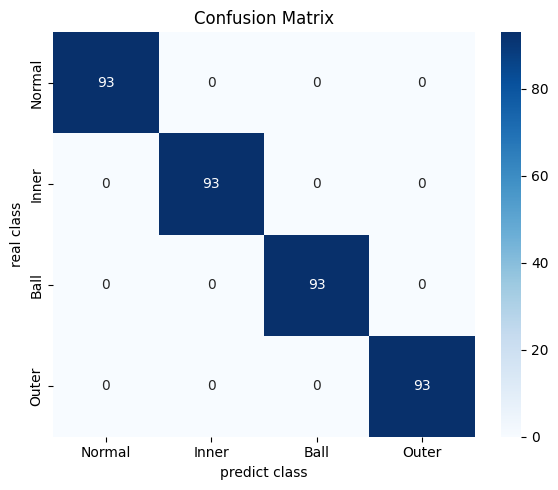


분류 리포트:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        93
       Inner       1.00      1.00      1.00        93
        Ball       1.00      1.00      1.00        93
       Outer       1.00      1.00      1.00        93

    accuracy                           1.00       372
   macro avg       1.00      1.00      1.00       372
weighted avg       1.00      1.00      1.00       372



In [41]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = np.argmax(model.predict(test_images, verbose=0), axis=1)
y_true = np.argmax(test_labels, axis=1)

cm = confusion_matrix(y_true, y_pred)
short_names = ['Normal', 'Inner', 'Ball', 'Outer']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names)
plt.xlabel('predict class')
plt.ylabel('real class')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print('\n분류 리포트:')
print(classification_report(y_true, y_pred, target_names=short_names))

### 문제 19. 모델을 저장하고 불러오세요. (Ch01과 동일)

In [40]:
# 모델 저장
model.save('./bearing_fault_rnn.h5')
print('모델 저장 완료: bearing_fault_rnn.h5')

# 모델 불러오기
loaded_model = tf.keras.models.load_model('./bearing_fault_rnn.h5')
loss, acc = loaded_model.evaluate(test_images, test_labels, verbose=0)
print(f'불러온 모델 정확도: {acc:.4f}')

모델 저장 완료: bearing_fault_rnn.h5
불러온 모델 정확도: 1.0000


---
## 정리 및 심화 과제

### 이번 실습에서 배운 것

| | Ch01 (MNIST) | 이번 실습 |
|---|---|---|
| 데이터 | 손글씨 이미지 (28×28) | 진동 신호 → reshape (32×32) |
| 전처리 | 0-1 정규화 | min-max 정규화 (음수 포함) |
| 모델 | SimpleRNN → Dense(10) | SimpleRNN → Dense(4) |
| 평가 | Accuracy | Accuracy + Confusion Matrix |

### 심화 과제 (도전해보세요)

1. **윈도우 크기 변경**: `window_size=512` 또는 `2048`로 바꿔서 성능 비교
2. **LSTM으로 교체**: `SimpleRNN` → `LSTM`으로 바꿔서 성능 비교
3. **결함 심각도 추가**: 같은 CWRU 데이터에서 0.007/0.014/0.021 inch 결함 크기로 심각도 분류
4. **스펙트로그램 활용**: `scipy.signal.spectrogram`으로 신호를 주파수 영역 이미지로 변환